In [1]:
# Imports - basic
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Configs
from config.config import CNN_Config

# Classes
from dataloader.load_data import LoadData
from model.cnn import ExplainableCNN
from model.sae import SAE
from trainer.trainer import Trainer

# Utils
from utils.hooks import Hooks


### Data, Loaders and Transforms


In [2]:
# Define transforms
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load Dataset
data = LoadData(transform=transform)
training_data, testing_data = data.load_data("CIFAR10")

# Data Loaders
train_loader = data.data_loaders(training_data, "train")
test_loader = data.data_loaders(testing_data, "test")

# Example visualization
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

Files already downloaded and verified
Files already downloaded and verified
torch.Size([10, 3, 32, 32]) torch.Size([10])


### Experiment 1 - Explainable CNN


#### Configuration


In [3]:
# Import configs
experiment_1_configs = CNN_Config['model_args']
experiment_1_configs

{'input_size': 3,
 'num_classes': 10,
 'hidden_layers': [64, 128, 256, 128, 64],
 'activation': torch.nn.modules.activation.ReLU,
 'norm_layer': torch.nn.modules.batchnorm.BatchNorm2d,
 'drop_prob': 0.4,
 'max_pool': False}

In [4]:
model = ExplainableCNN(input_size=experiment_1_configs['input_size'], hidden_layers=experiment_1_configs['hidden_layers'], 
                       num_classes=experiment_1_configs['num_classes'], activation=experiment_1_configs['activation'], 
                       normalization=experiment_1_configs['norm_layer'], max_pool=experiment_1_configs['max_pool'], 
                       drop_prob=experiment_1_configs['drop_prob'])

model

ExplainableCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=65536, out_features=10, bias=True)
  (relu): ReLU()
)

#### Model Training


In [5]:
criterion = CNN_Config['criterion']
optimizer = torch.optim.Adam(model.parameters(), lr=CNN_Config['learning_rate'])
batch_size = CNN_Config['batch_size']
epochs = CNN_Config['epochs']
experiment = CNN_Config['name']

model_trainer = Trainer(criterion=criterion, optimizer=optimizer, batch_size=batch_size, 
                        epochs=epochs, train_loader=train_loader, model=model, experiment=experiment)

model_trainer.train_model()

Starting Experiment: CNN_Experiment_1
Epoch: 1 / 1, step 100/5000, loss = 5.2874
Epoch: 1 / 1, step 200/5000, loss = 2.3579
Epoch: 1 / 1, step 300/5000, loss = 2.3043
Epoch: 1 / 1, step 400/5000, loss = 2.1380
Epoch: 1 / 1, step 500/5000, loss = 2.2485
Epoch: 1 / 1, step 600/5000, loss = 2.0665
Epoch: 1 / 1, step 700/5000, loss = 2.2931
Epoch: 1 / 1, step 800/5000, loss = 2.2702
Epoch: 1 / 1, step 900/5000, loss = 2.3350
Epoch: 1 / 1, step 1000/5000, loss = 1.7197
Epoch: 1 / 1, step 1100/5000, loss = 1.9765
Epoch: 1 / 1, step 1200/5000, loss = 1.6032
Epoch: 1 / 1, step 1300/5000, loss = 2.1484
Epoch: 1 / 1, step 1400/5000, loss = 2.0173
Epoch: 1 / 1, step 1500/5000, loss = 1.9395
Epoch: 1 / 1, step 1600/5000, loss = 1.8572
Epoch: 1 / 1, step 1700/5000, loss = 2.0773
Epoch: 1 / 1, step 1800/5000, loss = 2.2049
Epoch: 1 / 1, step 1900/5000, loss = 1.7047
Epoch: 1 / 1, step 2000/5000, loss = 1.5708
Epoch: 1 / 1, step 2100/5000, loss = 2.3153
Epoch: 1 / 1, step 2200/5000, loss = 1.7345
Epo

In [6]:
torch.save(model.state_dict(), 'model_weights.pth')

### Hooks and visualization


In [5]:
criterion = CNN_Config['criterion']
optimizer = torch.optim.Adam(model.parameters(), lr=CNN_Config['learning_rate'])
batch_size = CNN_Config['batch_size']
epochs = CNN_Config['epochs']
experiment = CNN_Config['name']

visual_model = ExplainableCNN(input_size=experiment_1_configs['input_size'], hidden_layers=experiment_1_configs['hidden_layers'], 
                       num_classes=experiment_1_configs['num_classes'], activation=experiment_1_configs['activation'], 
                       normalization=experiment_1_configs['norm_layer'], max_pool=experiment_1_configs['max_pool'], 
                       drop_prob=experiment_1_configs['drop_prob'])
visual_model.load_state_dict(torch.load('model_weights.pth'))
visual_model.eval()

/var/folders/lg/dkxq14195c770j5_whjgkvj80000gn/T/ipykernel_4435/394580717.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  visual_model.load_state_dict(torch.load('model

ExplainableCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=65536, out_features=10, bias=True)
  (relu): ReLU()
)

#### Define hook


In [6]:
# Collector of activations
collector = Hooks(model=visual_model, module_names=['conv1', 'conv3', 'conv5'])
collector.make_forward_hook()

In [7]:
# Perform forward pass to cllect activations
data, _ = testing_data[10]
data.unsqueeze_(0)
output_1 = visual_model(data)
collector.activations['conv5'].shape

torch.Size([1, 64, 32, 32])

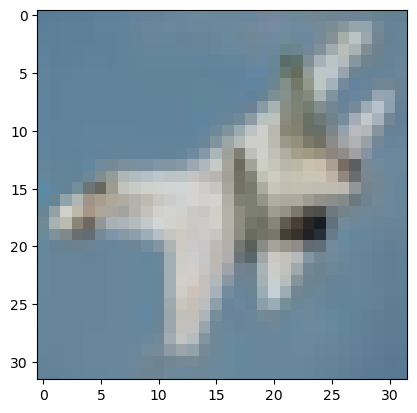

In [8]:
# Apply inverse transform for better visualization
invTransform = transforms.Normalize((-0.5/0.5, -0.5/0.5, -0.5/0.5), (1/0.5, 1/0.5, 1/0.5))
unnormalized = invTransform(testing_data[10][0])
plt.imshow(np.transpose(unnormalized, (1, 2, 0)))

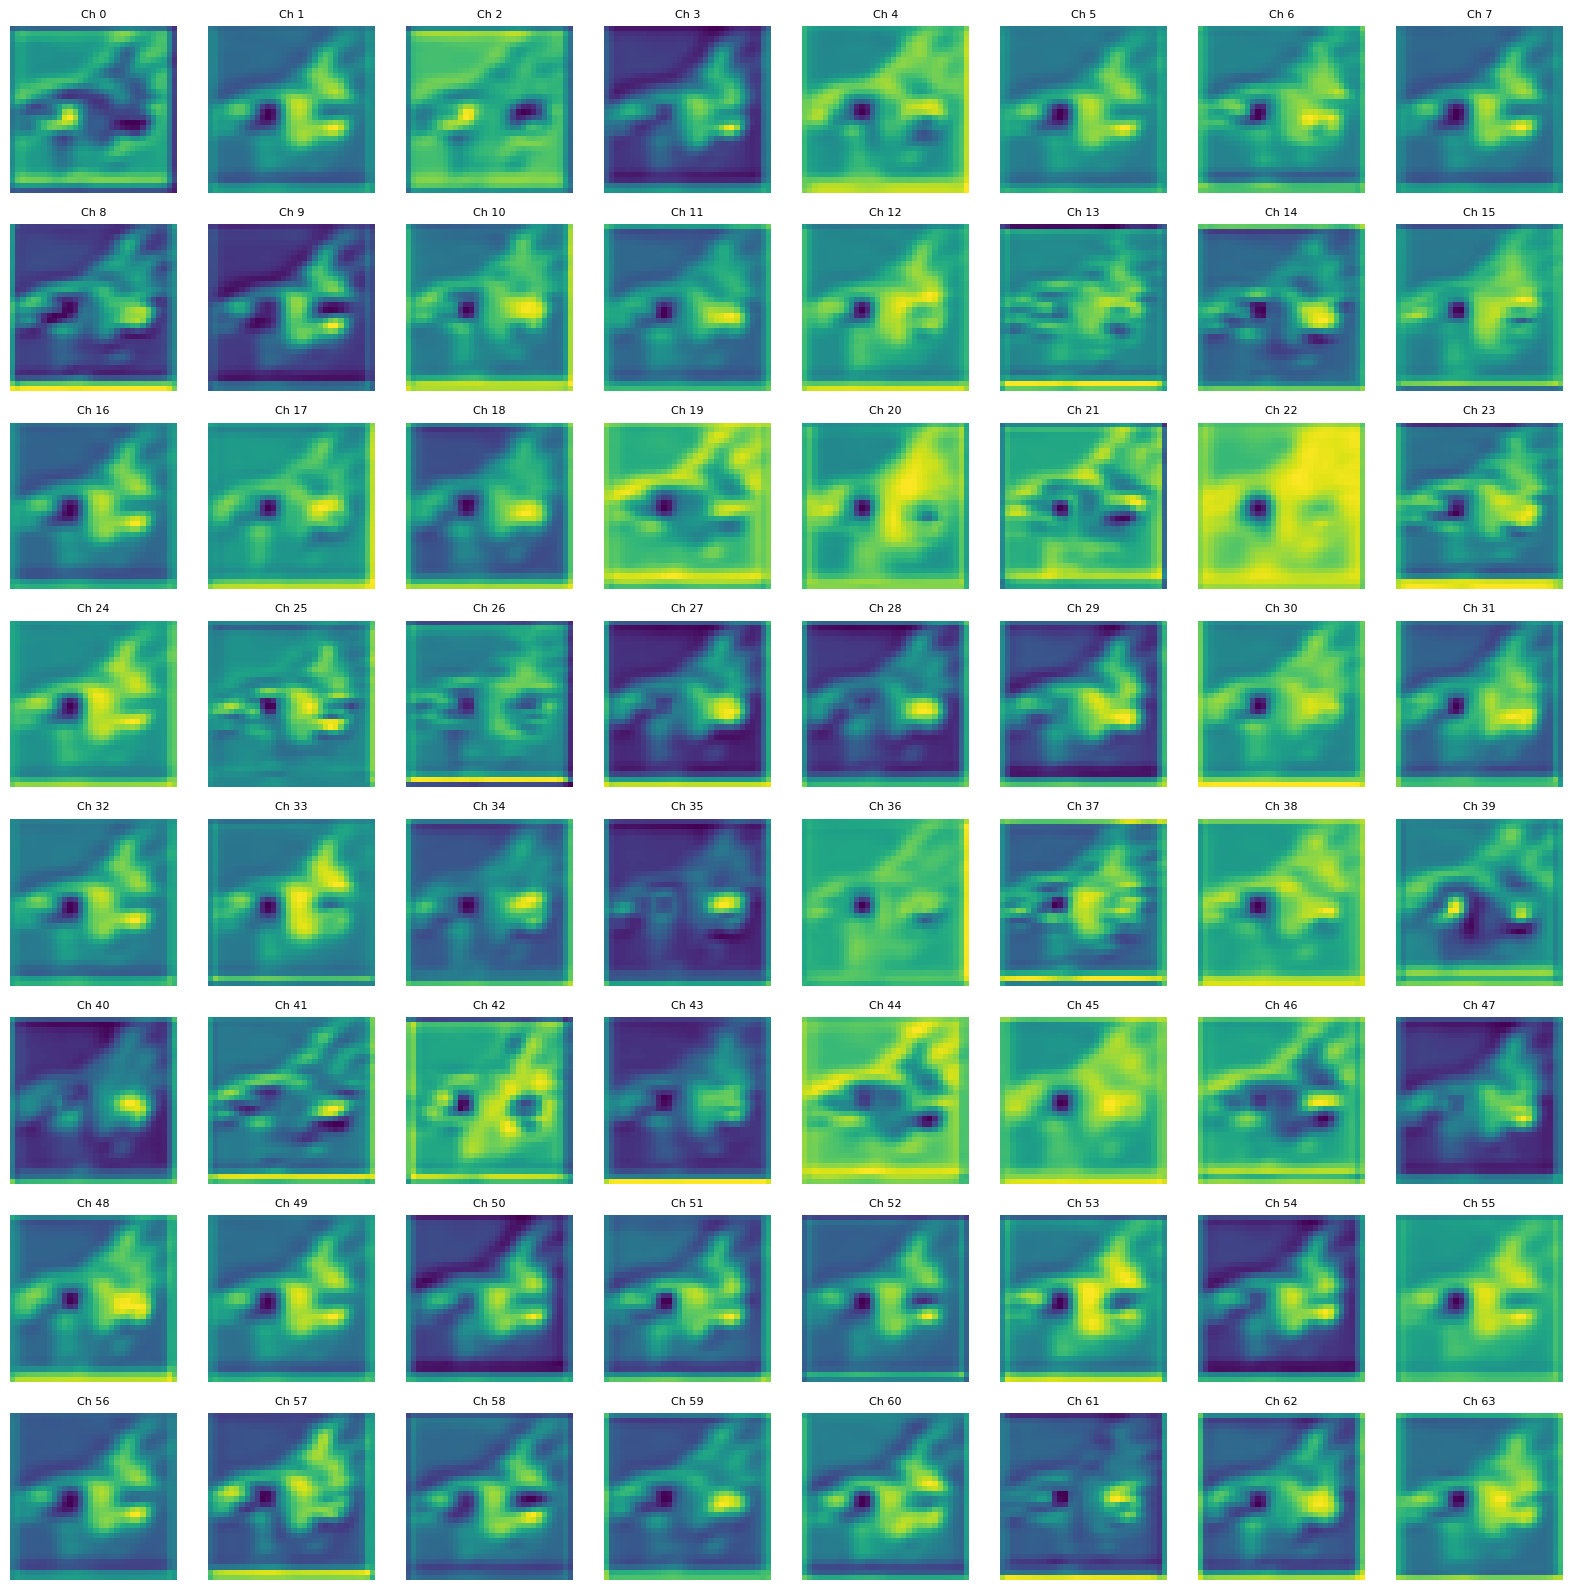

In [9]:
import math
act = collector.activations['conv5'].squeeze()   # shape: (C, H, W)
C = act.size(0)

# Normalize per-channel for better contrast
act = (act - act.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
      (act.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] - 
       act.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0] + 1e-6)

# Grid size
cols = int(math.sqrt(C))
rows = math.ceil(C / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i in range(C):
    axes[i].imshow(act[i].cpu(), cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Ch {i}", fontsize=8)

# Hide unused axes
for i in range(C, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


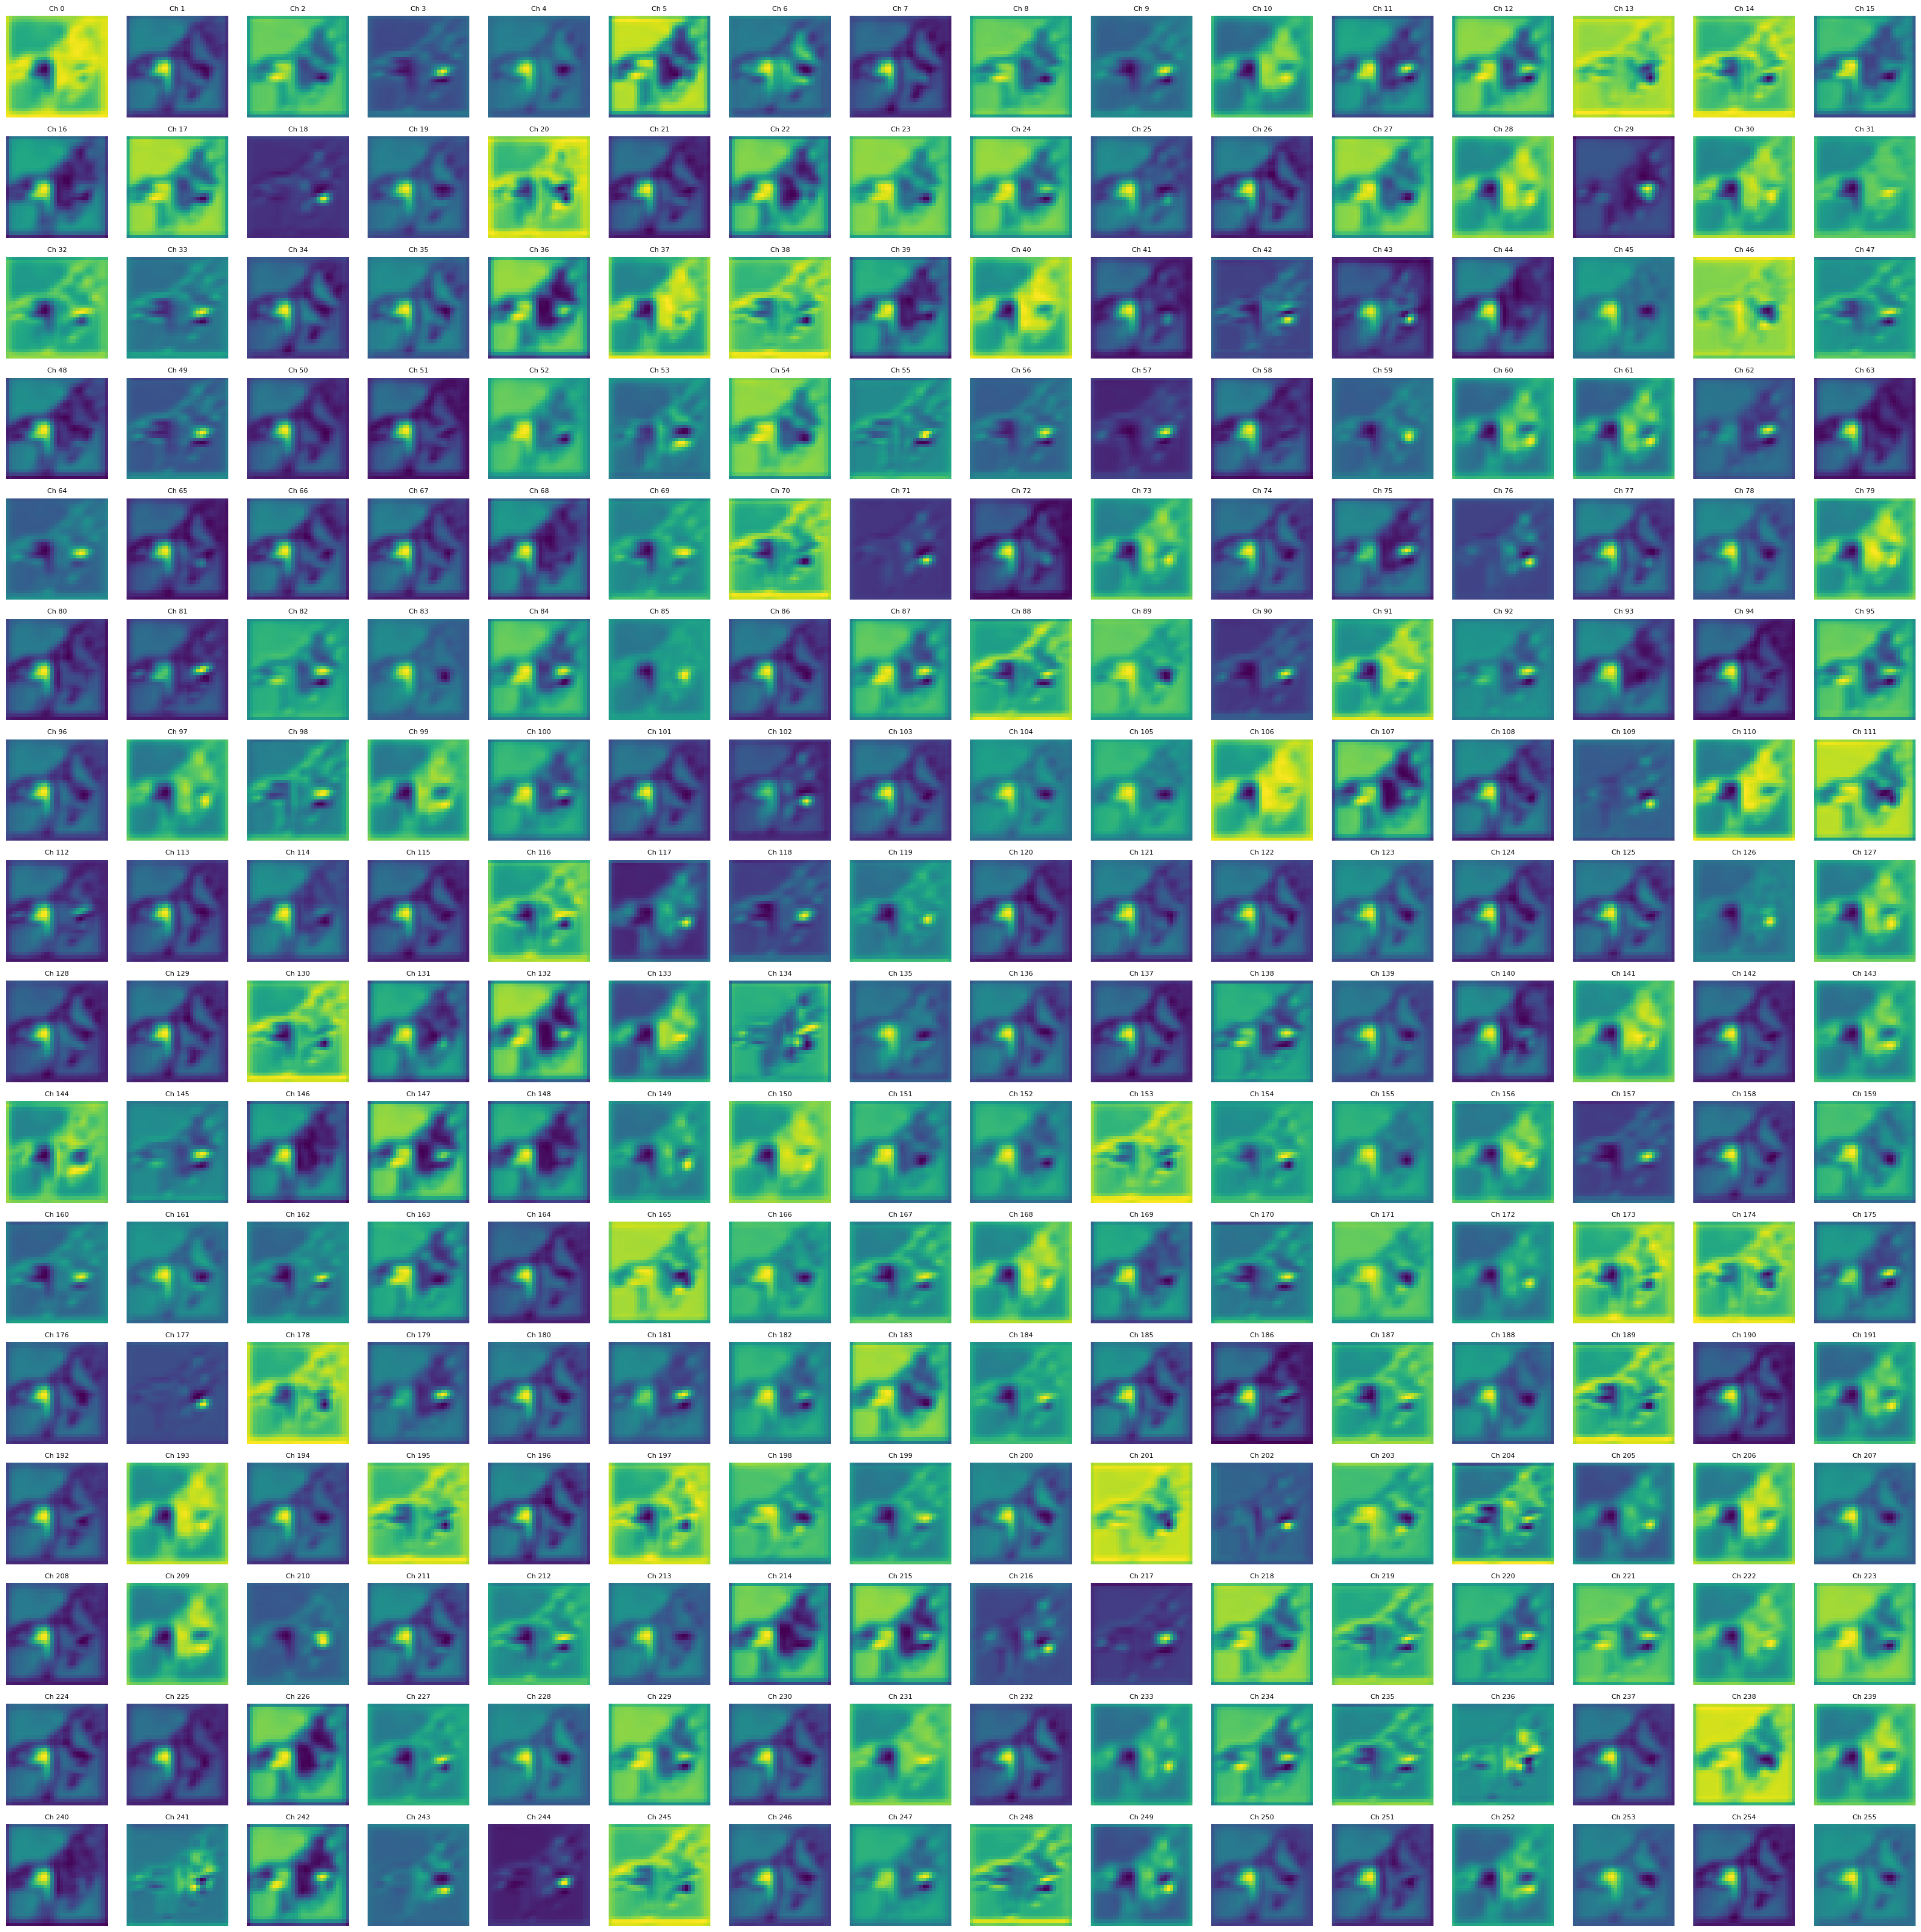

In [10]:
import math
act = collector.activations['conv3'].squeeze()   # shape: (C, H, W)
C = act.size(0)

# Normalize per-channel for better contrast
act = (act - act.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
      (act.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] - 
       act.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0] + 1e-6)

# Grid size
cols = int(math.sqrt(C))
rows = math.ceil(C / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i in range(C):
    axes[i].imshow(act[i].cpu(), cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Ch {i}", fontsize=8)

# Hide unused axes
for i in range(C, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

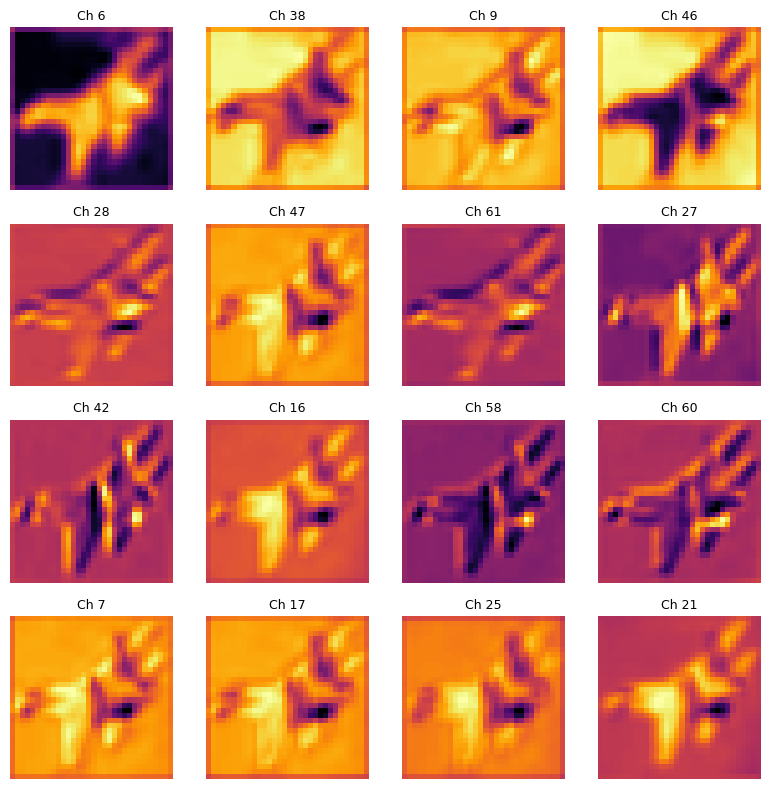

In [10]:
act = collector.activations['conv1'].squeeze()  # (C, H, W)

# Compute channel energy
energy = act.abs().mean(dim=(1, 2))
topk = torch.topk(energy, k=16).indices

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for ax, ch in zip(axes.flatten(), topk):
    fmap = act[ch]
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-6)
    ax.imshow(fmap.cpu(), cmap="inferno")
    ax.set_title(f"Ch {ch.item()}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
collector.remove()

### Collect feature vectors


In [12]:
feature_collector = Hooks(visual_model, ['conv5'])

In [ ]:
for i in range(5):
    data, _ = testing_data[i]
    data.unsqueeze_(0)
    output = visual_model(data)
    feature_collector.collect_features('conv5')

feature_collector.write_features(filepath="data/features.py")

len(feature_collector.feature_vectors)

5120

In [ ]:
feature_collector.remove()